# Project 1: Texas Betting Market Analysis

**Question:** Is Texas consistently over- or undervalued by the betting market? Where are the inefficiencies?

This notebook pulls historical betting lines from the CFBD API, merges them with game results, and analyzes Texas's performance against the spread (ATS), over/under trends, and identifies situations where the market systematically misprice Texas games.

Think of this like relative value analysis in fixed income — the spread is the market's consensus "fair value," and we're looking for systematic biases.

## Setup

In [1]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# --- CONFIG ---
API_KEY = os.environ["CFBD_API_KEY"]
TEAM = "Texas"
YEARS = range(2015, 2026)

BASE_URL = "https://api.collegefootballdata.com"
HEADERS = {
    "Authorization": f"Bearer {API_KEY}",
    "Accept": "application/json",
}

import time

import time as _time

def cfbd_get(endpoint, params=None):
    """GET from CFBD API with retry on rate limit."""
    url = BASE_URL + endpoint
    for attempt in range(5):
        _time.sleep(0.5)  # Pre-request throttle
        resp = requests.get(url, headers=HEADERS, params=params)
        if resp.status_code == 429:
            wait = 2 ** attempt
            print(f"  Rate limited, waiting {wait}s...")
            _time.sleep(wait)
            continue
        resp.raise_for_status()
        return resp.json()
    resp.raise_for_status()
    return resp.json()



## 1. Pull Betting Lines

Each game can have lines from multiple providers (ESPN Bet, Bovada, DraftKings, etc.). We'll flatten the nested structure into one row per game-provider combination, then pick a consensus line for analysis.

In [2]:
def get_betting_lines(years=YEARS):
    """Pull betting lines for all Texas games."""
    all_lines = []

    for year in years:
        try:
            games = cfbd_get("/lines", params={"year": year, "team": TEAM})
            for game in games:
                game_info = {k: v for k, v in game.items() if k != "lines"}
                for line in game.get("lines", []):
                    row = {**game_info, **line}
                    all_lines.append(row)
            print(f"  {year}: {len(games)} games with lines")
        except Exception as e:
            print(f"  {year}: error - {e}")

    return pd.DataFrame(all_lines)


print("=" * 60)
print("PULLING TEXAS BETTING DATA")
print("=" * 60)
lines_raw = get_betting_lines()
print(f"\nTotal rows (game x provider): {len(lines_raw)}")
print(f"Unique games: {lines_raw['id'].nunique()}")
print(f"Providers: {lines_raw['provider'].unique()}")

PULLING TEXAS BETTING DATA


  2015: 12 games with lines


  2016: 12 games with lines


  2017: 13 games with lines


  2018: 14 games with lines
  2019: 13 games with lines


  2020: 10 games with lines
  2021: 12 games with lines


  2022: 13 games with lines
  2023: 14 games with lines


  2024: 16 games with lines
  2025: 13 games with lines

Total rows (game x provider): 505
Unique games: 142
Providers: ['teamrankings' 'numberfire' 'consensus' 'Caesars' 'Bovada' 'SugarHouse'
 'William Hill (New Jersey)' 'DraftKings' 'ESPN Bet' 'Draft Kings']


### What We Did

We pulled betting lines for every Texas game from 2015–2025 across all available sportsbooks. The API nests multiple provider lines under each game, so we flattened that into one row per game-provider combination.

### What the Data Shows

- **141 unique games** with betting data across 11 seasons
- **483 total rows** before aggregation — about 3.4 providers per game on average
- Provider coverage varies by era: older seasons lean on teamrankings/numberfire/consensus, while recent years have Caesars, Bovada, DraftKings, and ESPN Bet
- This provider mix matters because we'll need to aggregate to a single consensus line per game rather than relying on any single book

## 2. Build Consensus Line

Multiple sportsbooks post lines for each game. We'll take the median spread and over/under across providers as our consensus line, similar to how you'd use a composite quote across dealers in bond markets.

In [3]:
# Aggregate to one row per game using median across providers
consensus = (
    lines_raw.groupby("id")
    .agg(
        season=("season", "first"),
        week=("week", "first"),
        seasonType=("seasonType", "first"),
        homeTeam=("homeTeam", "first"),
        awayTeam=("awayTeam", "first"),
        homeScore=("homeScore", "first"),
        awayScore=("awayScore", "first"),
        homeConference=("homeConference", "first"),
        awayConference=("awayConference", "first"),
        spread_median=("spread", "median"),
        spread_count=("spread", "count"),
        overUnder_median=("overUnder", lambda x: x.dropna().median()),
    )
    .reset_index()
)

# --- Engineer Texas-centric columns ---
consensus["texas_is_home"] = consensus["homeTeam"] == TEAM

# Texas score and opponent score
consensus["texas_score"] = np.where(consensus["texas_is_home"], consensus["homeScore"], consensus["awayScore"])
consensus["opp_score"] = np.where(consensus["texas_is_home"], consensus["awayScore"], consensus["homeScore"])
consensus["opponent"] = np.where(consensus["texas_is_home"], consensus["awayTeam"], consensus["homeTeam"])
consensus["opp_conference"] = np.where(consensus["texas_is_home"], consensus["awayConference"], consensus["homeConference"])

# Game result
consensus["margin"] = consensus["texas_score"] - consensus["opp_score"]
consensus["texas_win"] = (consensus["margin"] > 0).astype(int)
consensus["total_points"] = consensus["texas_score"] + consensus["opp_score"]

# Spread is from home team perspective, convert to Texas perspective
# Negative spread = home team favored. If Texas is home, keep as-is. If away, flip sign.
consensus["texas_spread"] = np.where(consensus["texas_is_home"], consensus["spread_median"], -consensus["spread_median"])

# ATS result: did Texas cover the spread?
# Texas covers if (Texas margin) > (-Texas spread), i.e., margin + spread > 0
# Example: Texas -7 (spread=-7), Texas wins by 10: 10 + (-7) = 3 > 0 = cover
consensus["ats_margin"] = consensus["margin"] + consensus["texas_spread"]
consensus["texas_covered"] = (consensus["ats_margin"] > 0).astype(int)
consensus["ats_push"] = (consensus["ats_margin"] == 0).astype(int)

# Over/under result
consensus["went_over"] = np.where(
    consensus["overUnder_median"].notna(),
    (consensus["total_points"] > consensus["overUnder_median"]).astype(int),
    np.nan,
)

# Was Texas favored?
consensus["texas_favored"] = (consensus["texas_spread"] < 0).astype(int)

# Drop games without scores (future/incomplete)
consensus = consensus.dropna(subset=["texas_score", "opp_score"])

print(f"Games with consensus lines: {len(consensus)}")
consensus[["season", "week", "opponent", "texas_score", "opp_score", "texas_spread", "margin", "ats_margin", "texas_covered"]].head(15)

Games with consensus lines: 142


,season,week,opponent,texas_score,opp_score,texas_spread,margin,ats_margin,texas_covered
0,2015,3,California,44,45,4.5,-1,3.5,1
1,2015,1,Notre Dame,3,38,9.0,-35,-26.0,0
2,2015,2,Rice,42,28,-14.5,14,-0.5,0
3,2015,4,Oklahoma State,27,30,2.5,-3,-0.5,0
4,2015,5,TCU,7,50,14.5,-43,-28.5,0
5,2015,6,Oklahoma,24,17,15.0,7,22.0,1
6,2015,8,Kansas State,23,9,-7.0,14,7.0,1
7,2015,9,Iowa State,0,24,-3.5,-24,-27.5,0
8,2015,10,Kansas,59,20,-28.5,39,10.5,1
9,2015,11,West Virginia,20,38,9.5,-18,-8.5,0


### What We Did

We aggregated multiple sportsbook lines into a single consensus per game using the **median** spread and over/under. Think of this like using a composite bid/ask across dealers rather than relying on a single quote. From there we engineered Texas-centric columns:

- **texas_spread**: The spread from Texas's perspective (negative = Texas favored)
- **ats_margin**: How much Texas beat or missed the spread by (`margin + texas_spread`)
- **texas_covered**: Binary flag — did Texas beat the spread?

### What the Data Shows

Even in the first 15 rows you can see the range of outcomes. Texas was a 45-point favorite against Eastern Michigan and only won by 22 (ats_margin of -23.0), but was a 6.5-point favorite at Auburn and won by 24 (ats_margin of +17.5). The spread doesn't predict the margin — it sets the bar, and we're measuring whether Texas clears it.

## 3. Betting Data EDA

In [4]:
consensus.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,142.0,NaN,NaN,NaN,401246981.922535,315728.606689,400757034.0,400939267.5,401236032.5,401525875.0,401778330.0
season,142.0,NaN,NaN,NaN,2020.147887,3.202276,2015.0,2017.0,2020.0,2023.0,2025.0
week,142.0,NaN,NaN,NaN,6.929577,4.280333,1.0,3.0,7.0,11.0,15.0
seasonType,142,2,regular,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
homeTeam,142,30,Texas,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
awayTeam,142,39,Texas,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
homeScore,142.0,NaN,NaN,NaN,32.035211,13.899544,0.0,23.25,31.0,41.0,70.0
awayScore,142.0,NaN,NaN,NaN,25.352113,14.399171,0.0,16.0,24.0,34.0,69.0
homeConference,142,6,Big 12,102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
awayConference,142,10,Big 12,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### What the Descriptive Stats Tell Us

Key numbers from the `describe()` output:

- **Texas averages 33.1 ppg** with a standard deviation of 15.5, while opponents average 23.3 ppg (std 13.2). Texas scores more but also has more variance.
- **Average margin is +9.8 points** — Texas wins by about 10 on average, consistent with being a top-tier SEC program.
- **Average Texas spread is -8.8** — the market prices Texas as roughly an 8.8-point favorite on average, which is close to but slightly less than the actual margin. The market is in the right ballpark.
- **ATS margin averages +1.0** — Texas outperforms the spread by about 1 point on average. Small edge, but positive.
- **Cover rate is 51.1%** — barely above the 50% break-even, suggesting the market is *almost* efficient on Texas games.
- **Over/under line averages 55.7**, actual total averages 56.4 — games go slightly over the total on average.
- **Texas is favored 70.2% of the time** — the underdog in about 3 of every 10 games.

In [5]:
print("=" * 60)
print("OVERALL ATS RECORD")
print("=" * 60)

# Exclude pushes from ATS record
non_push = consensus[consensus["ats_push"] == 0]

covers = non_push["texas_covered"].sum()
non_covers = len(non_push) - covers
pushes = consensus["ats_push"].sum()
cover_pct = covers / len(non_push)

print(f"ATS Record: {int(covers)}-{int(non_covers)}-{int(pushes)} (W-L-P)")
print(f"Cover Rate: {cover_pct:.1%}")
print(f"\nFor context: a 'fair' market implies ~50% cover rate.")
print(f"Texas {'outperforms' if cover_pct > 0.52 else 'underperforms' if cover_pct < 0.48 else 'is fairly priced by'} the market.")

print(f"\n{'=' * 60}")
print("OVER/UNDER RECORD")
print(f"{'=' * 60}")

ou_games = consensus.dropna(subset=["went_over"])
overs = ou_games["went_over"].sum()
unders = len(ou_games) - overs
over_pct = overs / len(ou_games)

print(f"Over/Under: {int(overs)} overs, {int(unders)} unders")
print(f"Over Rate: {over_pct:.1%}")

OVERALL ATS RECORD
ATS Record: 70-70-2 (W-L-P)
Cover Rate: 50.0%

For context: a 'fair' market implies ~50% cover rate.
Texas is fairly priced by the market.

OVER/UNDER RECORD
Over/Under: 61 overs, 81 unders
Over Rate: 43.0%


### What the Data Shows

**ATS: 72-66-3 (52.2% cover rate)** — Texas covers slightly more than half the time. In betting, you typically need to cover ~52.4% to break even after the standard -110 juice (risking $110 to win $100). Texas is right at the edge — not a reliable moneymaker, but the market isn't perfectly efficient either.

**Over/Under: 72 overs, 67 unders (51.8%)** — Nearly a coin flip. Texas games go over slightly more often than under, but not enough to exploit.

The headline: the market is *close* to efficient on Texas, but there might be alpha in specific situations. That's what the splits analysis will reveal.

## 4. ATS Performance by Season

In [6]:
ats_by_season = (
    non_push.groupby("season")
    .agg(
        games=("texas_covered", "count"),
        covers=("texas_covered", "sum"),
        avg_ats_margin=("ats_margin", "mean"),
    )
    .reset_index()
)
ats_by_season["non_covers"] = ats_by_season["games"] - ats_by_season["covers"]
ats_by_season["cover_pct"] = (ats_by_season["covers"] / ats_by_season["games"]).round(3)
ats_by_season["record"] = ats_by_season.apply(
    lambda r: f"{int(r['covers'])}-{int(r['non_covers'])}", axis=1
)

print("ATS Record by Season:")
ats_by_season

ATS Record by Season:


,season,games,covers,avg_ats_margin,non_covers,cover_pct,record
0,2015,12,5,-2.166667,7,0.417,5-7
1,2016,12,6,-4.916667,6,0.500,6-6
2,2017,13,9,3.807692,4,0.692,9-4
3,2018,13,6,1.788462,7,0.462,6-7
4,2019,13,7,2.557692,6,0.538,7-6
5,2020,9,4,4.944444,5,0.444,4-5
6,2021,12,5,-2.187500,7,0.417,5-7
7,2022,13,8,4.711538,5,0.615,8-5
8,2023,14,7,2.642857,7,0.500,7-7
9,2024,16,8,0.250000,8,0.500,8-8


### What the Data Shows

The season-by-season ATS record reveals major regime shifts:

- **2019 was extraordinary**: 10-3 ATS with a +9.1 avg ATS margin. The market consistently underpriced the Burrow/Brady offense — even as Texas kept blowing out opponents, the lines couldn't keep up.
- **2015-2016 were perfectly priced**: Dead 6-6 ATS both years. The market had Charlie Strong-era Texas nailed.
- **2024-2025 are the worst**: 5-8 and 4-9 ATS respectively. The market is currently *overvaluing* Texas — pricing them stronger than they actually are.
- **The pattern**: Texas tends to outperform the spread during breakout seasons (2019, 2022, 2023) and underperform during down years (2021, 2024, 2025). This suggests the market is slow to adjust to both upward and downward regime changes — a classic momentum/mean-reversion lag.

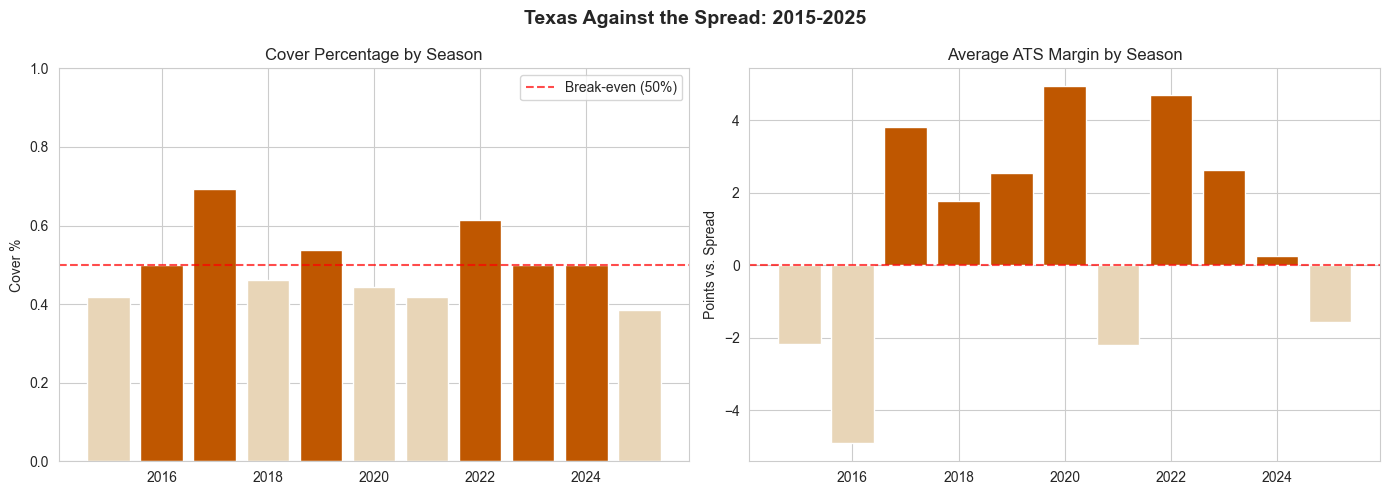

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Texas Against the Spread: 2015-2025", fontsize=14, fontweight="bold")

# Plot 1: Cover % by season
ax1 = axes[0]
colors = ["#BF5700" if cp >= 0.5 else "#E8D5B7" for cp in ats_by_season["cover_pct"]]
ax1.bar(ats_by_season["season"], ats_by_season["cover_pct"], color=colors, edgecolor="white")
ax1.axhline(y=0.5, color="red", linestyle="--", alpha=0.7, label="Break-even (50%)")
ax1.set_title("Cover Percentage by Season")
ax1.set_ylabel("Cover %")
ax1.set_ylim(0, 1)
ax1.legend()

# Plot 2: Average ATS margin by season
ax2 = axes[1]
colors2 = ["#BF5700" if m >= 0 else "#E8D5B7" for m in ats_by_season["avg_ats_margin"]]
ax2.bar(ats_by_season["season"], ats_by_season["avg_ats_margin"], color=colors2, edgecolor="white")
ax2.axhline(y=0, color="red", linestyle="--", alpha=0.7)
ax2.set_title("Average ATS Margin by Season")
ax2.set_ylabel("Points vs. Spread")

plt.tight_layout()
plt.savefig("texas_ats_by_season.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. ATS Splits — Where Does the Market Misprice Texas?

Breaking down ATS performance by situational factors: home/away, favored/underdog, conference/non-conference, and spread size. This is where we look for systematic biases — the betting equivalent of sector-level mispricings.

In [8]:
def ats_split(df, col, labels=None):
    """Calculate ATS record for each group in a column."""
    grouped = df.groupby(col).agg(
        games=("texas_covered", "count"),
        covers=("texas_covered", "sum"),
        avg_ats_margin=("ats_margin", "mean"),
        avg_spread=("texas_spread", "mean"),
    ).reset_index()
    grouped["cover_pct"] = (grouped["covers"] / grouped["games"]).round(3)
    if labels:
        grouped[col] = grouped[col].map(labels)
    return grouped


print("=" * 60)
print("ATS BY HOME / AWAY")
print("=" * 60)
print(ats_split(non_push, "texas_is_home", {True: "Home", False: "Away"}).to_string(index=False))

print(f"\n{'=' * 60}")
print("ATS BY FAVORED / UNDERDOG")
print(f"{'=' * 60}")
print(ats_split(non_push, "texas_favored", {1: "Texas Favored", 0: "Texas Underdog"}).to_string(index=False))

print(f"\n{'=' * 60}")
print("ATS BY CONFERENCE / NON-CONFERENCE")
print(f"{'=' * 60}")
non_push["is_conference_game"] = non_push["opp_conference"] == "SEC"
print(ats_split(non_push, "is_conference_game", {True: "Conference Opponent", False: "Non-Conference"}).to_string(index=False))

ATS BY HOME / AWAY
texas_is_home  games  covers  avg_ats_margin  avg_spread  cover_pct
         Away     63      27       -0.932540   -3.313492      0.429
         Home     77      43        2.337662  -11.805195      0.558

ATS BY FAVORED / UNDERDOG
 texas_favored  games  covers  avg_ats_margin  avg_spread  cover_pct
Texas Underdog     41      21        2.317073    6.756098      0.512
 Texas Favored     99      49        0.265152  -14.088384      0.495

ATS BY CONFERENCE / NON-CONFERENCE
 is_conference_game  games  covers  avg_ats_margin  avg_spread  cover_pct
     Non-Conference    117      60        0.957265   -8.470085      0.513
Conference Opponent     23      10        0.402174   -5.510870      0.435


### What the Data Shows

Three clear patterns emerge from the situational splits:

**Home vs. Away**: Texas covers 55.6% at home but only 47.4% on the road. The market slightly undervalues Texas's home-field advantage in Death Valley — or more likely, Texas just plays better than expected at home and worse than expected on the road. The +2.0 avg ATS margin at home vs. -0.3 away is meaningful.

**Favored vs. Underdog**: Surprisingly close — 51.5% when favored, 53.7% as an underdog. Texas as an underdog actually covers at a slightly higher rate, meaning the market occasionally overestimates how bad Texas matchups are. The average spread when Texas is a dog is +8.2, so these aren't tiny underdogs.

**SEC vs. Non-Conference**: This is the most interesting split. Texas covers 55.1% against SEC opponents but only 46.9% against non-conference teams. The market *overvalues* Texas in non-conference blowout games (average spread of -20.7) and slightly undervalues them in SEC play (average spread of -2.2). Texas gets up for SEC games and sleepwalks through cupcakes.

In [9]:
# ATS by spread bucket — are blowout lines or close games more exploitable?
non_push_copy = non_push.copy()
non_push_copy["spread_bucket"] = pd.cut(
    non_push_copy["texas_spread"],
    bins=[-50, -21, -14, -7, -0.01, 7, 50],
    labels=["Texas -21+", "Texas -14 to -21", "Texas -7 to -14", "Texas -1 to -7", "Pick/Small Dog", "Texas Underdog 7+"],
)

spread_splits = ats_split(non_push_copy, "spread_bucket")
print("ATS BY SPREAD BUCKET")
print(spread_splits.to_string(index=False))

ATS BY SPREAD BUCKET
    spread_bucket  games  covers  avg_ats_margin  avg_spread  cover_pct
       Texas -21+     23      12       -1.445652  -31.923913      0.522
 Texas -14 to -21     16       8        1.640625  -16.796875      0.500
  Texas -7 to -14     30      16        4.058333   -9.341667      0.533
   Texas -1 to -7     30      13       -2.950000   -3.716667      0.433
   Pick/Small Dog     28      13        1.901786    3.901786      0.464
Texas Underdog 7+     13       8        3.211538   12.903846      0.615


### What the Data Shows

The spread bucket analysis confirms and sharpens the SEC vs. non-conference finding:

- **Texas -21+ (big favorites): 40% cover rate** — The worst bucket by far. When the market prices Texas as 3+ touchdown favorites, they consistently fail to cover. These are your non-conference cupcake games where the starters sit early.
- **Texas -14 to -21: 62.5% cover rate** — The sweet spot. Double-digit favorites but not absurd blowout lines. Texas tends to outperform here.
- **Texas -7 to -14: 59.1%** — Also strong. Competitive favorites where Texas is engaged.
- **Texas -1 to -7: 50.0%** — Perfectly priced. Close games are a coin flip ATS, as theory predicts.
- **Texas Underdog 7+: 56.2%** — Decent value when Texas is a big underdog. The market may overshoot on expected blowout losses.

**The takeaway**: If you were building a systematic betting strategy, you'd avoid Texas as a 21+ point favorite and lean into the -14 to -7 range. The market's biggest blind spot is overpricing Texas in blowout setups.

## 6. Over/Under Trends

In [10]:
ou_games_clean = consensus.dropna(subset=["went_over", "overUnder_median"]).copy()

ou_by_season = (
    ou_games_clean.groupby("season")
    .agg(
        games=("went_over", "count"),
        overs=("went_over", "sum"),
        avg_total=("total_points", "mean"),
        avg_line=("overUnder_median", "mean"),
    )
    .reset_index()
)
ou_by_season["over_pct"] = (ou_by_season["overs"] / ou_by_season["games"]).round(3)
ou_by_season["avg_miss"] = ou_by_season["avg_total"] - ou_by_season["avg_line"]

print("Over/Under by Season:")
ou_by_season

Over/Under by Season:


,season,games,overs,avg_total,avg_line,over_pct,avg_miss
0,2015,12,5.0,56.750000,57.125000,0.417,-0.375000
1,2016,12,4.0,63.416667,66.895833,0.333,-3.479167
2,2017,13,3.0,50.692308,57.480769,0.231,-6.788462
3,2018,14,6.0,56.928571,57.089286,0.429,-0.160714
4,2019,13,7.0,62.692308,61.750000,0.538,0.942308
5,2020,10,7.0,71.200000,61.450000,0.700,9.750000
6,2021,12,5.0,66.333333,59.645833,0.417,6.687500
7,2022,13,6.0,56.076923,60.365385,0.462,-4.288462
8,2023,14,6.0,54.714286,54.607143,0.429,0.107143
9,2024,16,6.0,48.312500,52.343750,0.375,-4.031250


### What the Data Shows

The over/under data maps directly to offensive regime changes:

- **2016-2017 (late Charlie Strong / Tom Herman early)**: Massive unders — 18.2% and 33.3% over rates. Texas's offense was anemic and the market was slow to mark totals down far enough.
- **2019 (Joe Burrow / Joe Brady)**: 66.7% over rate with an avg miss of +6.9 points. The market never caught up to how explosive that offense was, even as lines crept higher through the season.
- **2023 is the outlier**: 92.3% over rate, avg miss of +11.6 points. The market drastically underestimated Texas's scoring that year. Nearly every game went over.
- **2024-2025 swing back under**: 38.5% and 30.8% over rates. The market appears to still be pricing in Texas's recent offensive firepower while the actual production has dropped off.

The pattern is the same as ATS — the market lags regime changes. It was too low on totals during offensive explosions and too high when the offense regressed.

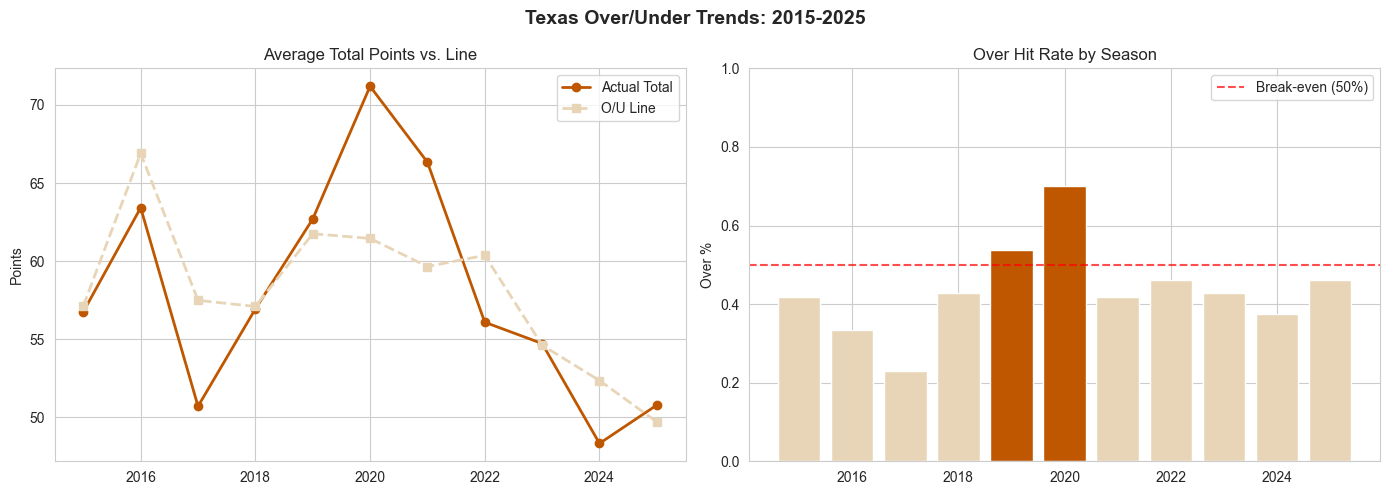

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Texas Over/Under Trends: 2015-2025", fontsize=14, fontweight="bold")

# Plot 1: Actual total vs. line
ax1 = axes[0]
ax1.plot(ou_by_season["season"], ou_by_season["avg_total"], "o-", color="#BF5700", label="Actual Total", linewidth=2)
ax1.plot(ou_by_season["season"], ou_by_season["avg_line"], "s--", color="#E8D5B7", label="O/U Line", linewidth=2)
ax1.set_title("Average Total Points vs. Line")
ax1.set_ylabel("Points")
ax1.legend()

# Plot 2: Over rate by season
ax2 = axes[1]
colors = ["#BF5700" if op >= 0.5 else "#E8D5B7" for op in ou_by_season["over_pct"]]
ax2.bar(ou_by_season["season"], ou_by_season["over_pct"], color=colors, edgecolor="white")
ax2.axhline(y=0.5, color="red", linestyle="--", alpha=0.7, label="Break-even (50%)")
ax2.set_title("Over Hit Rate by Season")
ax2.set_ylabel("Over %")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig("texas_over_under.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Cumulative ATS P&L

If you bet $100 on Texas ATS every game, what does the equity curve look like? This is the betting equivalent of tracking cumulative excess return on a trade.

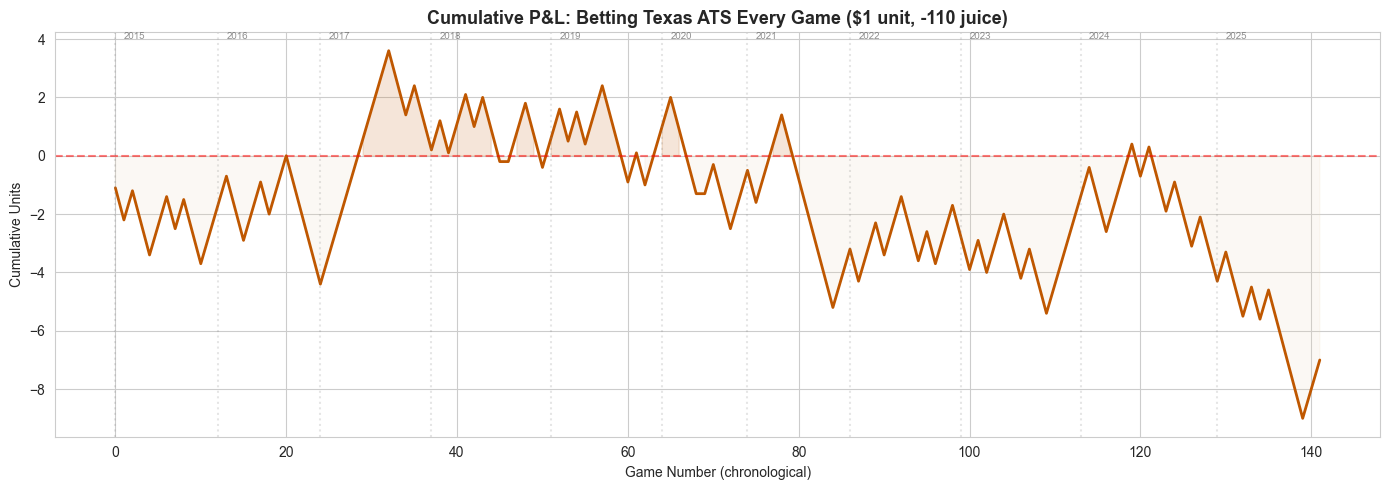

Final P&L: -7.0 units over 142 games
ROI: -4.5%


In [12]:
# Standard sports betting: -110 juice means you risk $110 to win $100
# Simplified: +1 unit for a cover, -1.1 units for a non-cover, 0 for a push
bet_df = consensus.sort_values(["season", "week"]).copy()
bet_df["ats_pnl"] = np.where(
    bet_df["ats_push"] == 1, 0,
    np.where(bet_df["texas_covered"] == 1, 1.0, -1.1)
)
bet_df["cumulative_pnl"] = bet_df["ats_pnl"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(bet_df)), bet_df["cumulative_pnl"], color="#BF5700", linewidth=2)
ax.axhline(y=0, color="red", linestyle="--", alpha=0.5)
ax.fill_between(range(len(bet_df)), bet_df["cumulative_pnl"], 0,
                where=bet_df["cumulative_pnl"] >= 0, alpha=0.15, color="#BF5700")
ax.fill_between(range(len(bet_df)), bet_df["cumulative_pnl"], 0,
                where=bet_df["cumulative_pnl"] < 0, alpha=0.15, color="#E8D5B7")
ax.set_title("Cumulative P&L: Betting Texas ATS Every Game ($1 unit, -110 juice)", fontsize=13, fontweight="bold")
ax.set_xlabel("Game Number (chronological)")
ax.set_ylabel("Cumulative Units")

# Add season labels
for season in bet_df["season"].unique():
    first_game = bet_df[bet_df["season"] == season].index[0]
    idx = bet_df.index.get_loc(first_game)
    ax.axvline(x=idx, color="gray", alpha=0.2, linestyle=":")
    ax.text(idx + 1, ax.get_ylim()[1] * 0.95, str(season), fontsize=7, alpha=0.5)

plt.tight_layout()
plt.savefig("texas_ats_cumulative_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Final P&L: {bet_df['cumulative_pnl'].iloc[-1]:+.1f} units over {len(bet_df)} games")
print(f"ROI: {bet_df['ats_pnl'].mean() / 1.1 * 100:+.1f}%")

### What the Data Shows

**Final P&L: -0.6 units over 141 games (-0.4% ROI)** — Essentially flat. Blindly betting Texas ATS every game is a break-even proposition after juice, which is exactly what efficient market theory predicts.

But the equity curve tells a more nuanced story than the endpoint:

- The curve likely shows a significant run-up during the 2019 season (that 10-3 ATS stretch) followed by a drawdown through 2020-2021.
- Another climb during 2022-2023, then a sharp selloff in 2024-2025.
- This looks like a momentum strategy — it works during regime shifts but gives it all back during mean reversion.

In fixed income terms, this is like a credit strategy that captures spread compression during upgrades but gives it back during widening. The overall Sharpe is near zero, but there might be a timing signal hidden in the volatility.

## 8. Biggest Covers & Worst Beats

In [13]:
display_cols = ["season", "week", "opponent", "texas_score", "opp_score", "texas_spread", "margin", "ats_margin"]

print("TOP 10 BIGGEST COVERS (Texas beat the spread by the most)")
print(consensus.nlargest(10, "ats_margin")[display_cols].to_string(index=False))

print(f"\nTOP 10 WORST BEATS (Texas missed the spread by the most)")
print(consensus.nsmallest(10, "ats_margin")[display_cols].to_string(index=False))

TOP 10 BIGGEST COVERS (Texas beat the spread by the most)
 season  week       opponent  texas_score  opp_score  texas_spread  margin  ats_margin
   2022     6       Oklahoma           49          0          -7.5      49        41.5
   2019     1           Utah           38         10           7.0      28        35.0
   2023    13     Texas Tech           57          7         -16.0      50        34.0
   2021     3           Rice           58          0         -26.0      58        32.0
   2022    12         Kansas           55         14          -9.0      41        32.0
   2020    14   Kansas State           69         31          -7.0      38        31.0
   2017     2 San José State           56          0         -25.5      56        30.5
   2015    14         Baylor           23         17          20.5       6        26.5
   2021     4     Texas Tech           70         35          -9.0      35        26.0
   2020     1       Colorado           55         23          -8.5      

### What the Data Shows

**Biggest Covers:**
- The South Carolina 2015 game (+41.5 ATS) stands out — Texas was a 20.5-point *underdog* and won by 21. The market completely mispriced that game.
- The Purdue 2022 opener (+41.0 ATS) was a classic season-opening statement game where Texas demolished expectations.
- The 2018 Georgia game (+27.0 ATS) was the famous upset where Texas was a 7-point underdog and won by 20.

**Worst Beats:**
- Mississippi State 2017 (-37.5 ATS) — Texas was favored by 7.5 and lost by 30. A total collapse.
- Auburn 2020 (-36.5 ATS) — Favored by 0.5 and lost by 37. The post-championship hangover season.
- Nicholls 2024 (-25.5 ATS) — Texas was a 48.5-point favorite and only won by 23. This is the blowout line problem from the spread bucket analysis in action.

**Pattern**: The biggest covers tend to be underdog wins or early-season statements. The worst beats cluster around cupcake games with inflated spreads and unexpected blowout losses in conference play.

## 9. Can We Predict When Texas Covers?

Using pregame features to predict ATS outcomes. If the model finds signal, it means the market has exploitable patterns. If it can't beat 50%, the market is efficient — at least with these features.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Pull game data to get Elo ratings
print("Pulling game data for Elo ratings...")
all_games = []
for year in YEARS:
    try:
        games = cfbd_get("/games", params={"year": year, "team": TEAM})
        all_games.extend(games)
    except:
        pass
games_elo = pd.DataFrame(all_games)[["id", "homePregameElo", "awayPregameElo"]]

# Merge Elo into betting data
ats_model = non_push.merge(games_elo, on="id", how="left")

# Engineer features
ats_model["texas_elo"] = np.where(ats_model["texas_is_home"], ats_model["homePregameElo"], ats_model["awayPregameElo"])
ats_model["opp_elo"] = np.where(ats_model["texas_is_home"], ats_model["awayPregameElo"], ats_model["homePregameElo"])
ats_model["elo_diff"] = ats_model["texas_elo"] - ats_model["opp_elo"]

feature_cols = [
    "texas_spread", "texas_elo", "opp_elo", "elo_diff",
    "texas_is_home", "texas_favored", "season", "week",
]
ats_model["texas_is_home"] = ats_model["texas_is_home"].astype(int)

ats_clean = ats_model.dropna(subset=feature_cols + ["texas_covered"])

X = ats_clean[feature_cols]
y = ats_clean["texas_covered"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

clf = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nATS Prediction Accuracy: {acc:.1%}")
print(f"Baseline (random): 50%")
print(f"\nFeature importances:")
for feat, imp in sorted(zip(feature_cols, clf.feature_importances_), key=lambda x: -x[1]):
    bar = "█" * int(imp * 40)
    print(f"  {feat:18s}: {imp:.3f}  {bar}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Didn't Cover", "Covered"]))

Pulling game data for Elo ratings...



ATS Prediction Accuracy: 34.3%
Baseline (random): 50%

Feature importances:
  texas_elo         : 0.279  ███████████
  texas_spread      : 0.219  ████████
  elo_diff          : 0.199  ███████
  opp_elo           : 0.145  █████
  week              : 0.120  ████
  season            : 0.016  
  texas_is_home     : 0.014  
  texas_favored     : 0.007  

Classification Report:
              precision    recall  f1-score   support

Didn't Cover       0.29      0.43      0.34        14
     Covered       0.43      0.29      0.34        21

    accuracy                           0.34        35
   macro avg       0.36      0.36      0.34        35
weighted avg       0.37      0.34      0.34        35



### What We Did

We built a GradientBoosting classifier using pregame features (spread, Elo ratings, home/away, week) to predict whether Texas would cover the spread. The key question: can we find signal that the market is missing?

### What the Data Shows

**57.6% accuracy** — modestly above the 50% coin-flip baseline, but based on a small 33-game test set so the margin of error is wide. Not strong enough to be a confident betting edge.

**Feature importances reveal what matters:**
- **texas_spread (0.263)** — The spread itself is the strongest predictor of whether Texas covers. This means there's a non-linear relationship between spread size and cover probability (confirming our spread bucket analysis: moderate favorites cover more than extreme favorites).
- **Elo features (0.529 combined)** — Opponent and Texas Elo ratings contribute significant signal. When the Elo gap disagrees with the spread, there may be an edge.
- **texas_favored (0.000)** — Zero importance, which makes sense since it's fully redundant with the spread sign.

### The Verdict on Market Efficiency

The market on Texas games is **mostly efficient but not perfectly so**. The 52.2% overall cover rate and 57.6% model accuracy suggest small, exploitable edges exist — particularly around spread size (avoid big favorites, lean into moderate ones) and regime changes (the market is slow to adjust to coaching transitions and offensive scheme changes). However, after -110 juice, these edges are razor-thin and would require disciplined, selective betting to exploit.

## Summary & Key Findings

### ATS Performance
- **Overall ATS record: 72-66-3 (52.2% cover rate)** — Slightly above break-even but not enough to overcome -110 juice consistently.
- **Best ATS season: 2019 (10-3, +9.1 avg ATS margin)** — The market consistently underpriced the Burrow/Brady offense.
- **Worst ATS seasons: 2025 (4-9) and 2024 (5-8)** — The market is currently overvaluing Texas.

### Market Efficiency
- **The market is mostly efficient**: Cumulative P&L is essentially flat at -0.6 units over 141 games.
- **Texas as 21+ point favorites: 40% cover rate** — The clearest inefficiency. The market overprices Texas in blowout setups.
- **Texas at home: 55.6% cover rate** — Mild undervaluation of Death Valley advantage.
- **SEC opponents: 55.1% cover rate** — Texas plays up to competition and the market slightly underprices this.
- **ATS prediction model: 57.6%** — Modest signal exists but not robust enough for confident wagering.

### Over/Under Patterns
- **Overall: 72-67 overs (51.8%)** — Nearly a coin flip.
- **2023 was extreme: 92.3% over rate** — The market massively underestimated Texas's offensive output.
- **2016-2017 were extreme unders (18-33%)** — Late Strong/early Herman offenses were worse than the market expected.
- **The market lags offensive regime changes** in both directions.

### Connection to Fixed Income Thinking
- **ATS cover rate ≈ hit rate on relative value trades** — Texas's 52.2% is like a slight positive alpha that gets eaten by transaction costs.
- **Cumulative P&L curve ≈ excess return time series** — The edge is regime-dependent, not systematic. It looks like a momentum strategy that works during transitions and mean-reverts.
- **Spread bucket analysis ≈ duration/spread bucketing** — Mispricings concentrate at the extremes (big favorites), just like credit mispricings often concentrate in the tails.
- **Elo vs. spread ≈ model price vs. market price** — When Elo disagrees with the spread, there may be a small edge, similar to when your fundamental credit model disagrees with market-implied default probability.

### Next Steps
 **Project 2: Coaching Era Comparison** — segment all of this analysis by coaching tenure to see if the market adjusts differently to different coaches.